In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
import matplotlib.pyplot as plt

print("TF", tf.__version__)

TF 2.21.0


tf_flowers from TensorFlow Datasets has 5 classes, each with well over 100 images. We split it 70% train, 15% validation, 15% test.

In [2]:
(train_raw, valid_raw, test_raw), info = tfds.load(
    "tf_flowers",
    split=["train[:70%]", "train[70%:85%]", "train[85%:]"],
    as_supervised=True,
    with_info=True,
)

n_classes = info.features["label"].num_classes
class_names = info.features["label"].names
print(n_classes, class_names)

5 ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


In [3]:
print("Train:", train_raw.cardinality().numpy())
print("Valid:", valid_raw.cardinality().numpy())
print("Test:", test_raw.cardinality().numpy())

Train: 2569
Valid: 551
Test: 550


A few sample images.

I0000 00:00:1785733149.986302 17034232 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
W0000 00:00:1785733150.133885 17034237 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


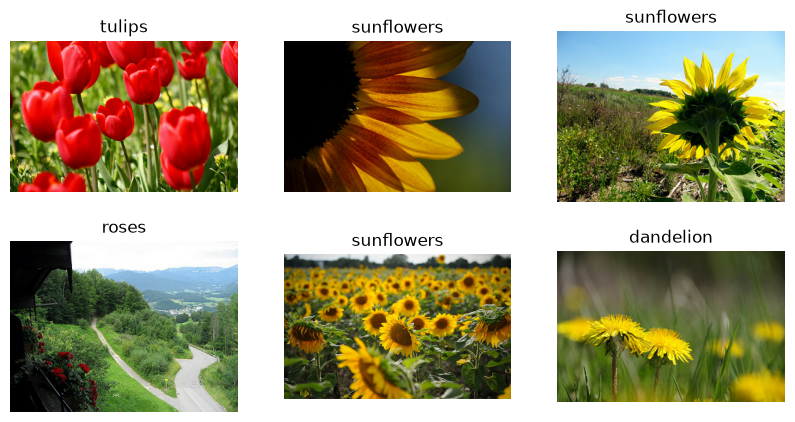

In [4]:
plt.figure(figsize=(10, 5))
for i, (image, label) in enumerate(train_raw.take(6)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")
plt.show()

Input pipeline: resize to 224x224, add data augmentation on the training set only, apply MobileNetV2 preprocessing, then batch and prefetch.

In [5]:
img_size = 224
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.2),
])


def prepare(ds, training=False):
    ds = ds.map(lambda x, y: (tf.image.resize(x, [img_size, img_size]), y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(1000)
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (keras.applications.mobilenet_v2.preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)


train_set = prepare(train_raw, training=True)
valid_set = prepare(valid_raw)
test_set = prepare(test_raw)

Build the model: a MobileNetV2 base pretrained on ImageNet with its weights frozen, plus a new classification head for the 5 flower classes.

In [6]:
base_model = keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=[img_size, img_size, 3],
)
base_model.trainable = False

model = keras.Sequential([
    keras.layers.Input(shape=[img_size, img_size, 3]),
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(n_classes, activation="softmax"),
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

First train only the new head, with the base frozen.

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(train_set, validation_data=valid_set, epochs=5)

Epoch 1/5


/Users/ducnguyen/Desktop/AIT506/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - accuracy: 0.6882 - loss: 0.8273 - val_accuracy: 0.8258 - val_loss: 0.4868
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - accuracy: 0.8412 - loss: 0.4438 - val_accuracy: 0.8494 - val_loss: 0.4107
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - accuracy: 0.8715 - loss: 0.3631 - val_accuracy: 0.8730 - val_loss: 0.3636
Epoch 4/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.8859 - loss: 0.3212 - val_accuracy: 0.8875 - val_loss: 0.3330
Epoch 5/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - accuracy: 0.9027 - loss: 0.2910 - val_accuracy: 0.8966 - val_loss: 0.3173


Fine-tune: unfreeze the top of the base and train again with a very low learning rate so the pretrained weights are only adjusted slightly.

In [8]:
base_model.trainable = True

# Keep the lower layers frozen, fine-tune only the top
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_fine = model.fit(train_set, validation_data=valid_set, epochs=5)

Epoch 1/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 204ms/step - accuracy: 0.8174 - loss: 0.5124 - val_accuracy: 0.8875 - val_loss: 0.3316
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 202ms/step - accuracy: 0.8715 - loss: 0.3691 - val_accuracy: 0.8857 - val_loss: 0.3280
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - accuracy: 0.8891 - loss: 0.3266 - val_accuracy: 0.8966 - val_loss: 0.3069
Epoch 4/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - accuracy: 0.9039 - loss: 0.2832 - val_accuracy: 0.9038 - val_loss: 0.2908
Epoch 5/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 200ms/step - accuracy: 0.9066 - loss: 0.2720 - val_accuracy: 0.9038 - val_loss: 0.2823


Evaluate on the test set.

In [9]:
test_loss, test_acc = model.evaluate(test_set)
print(f"Test accuracy: {test_acc:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.9273 - loss: 0.2286 
Test accuracy: 0.9273
